# TDA vs. Baselines: Interaction Detection Benchmark

This notebook benchmarks **5 interaction detection methods** on tabular datasets:

1. **TDA** — Persistent homology via distance correlation → Vietoris-Rips complex (GUDHI)
2. **ANOVA** — F-test for interaction terms with Bonferroni correction
3. **MI Screening** — Mutual information synergy detection
4. **Tree-based** — Random Forest split co-occurrence analysis
5. **Correlation** — Pearson correlation → maximal clique detection

Each method uses a **precompute + threshold sweep** strategy: expensive per-fold computations are cached, then thresholds are swept cheaply against those cached results. Results are evaluated against ground-truth interactions (when available) using exact and superset match F1 scores.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# gudhi, dcor, loguru — NOT on Colab, always install
_pip('gudhi>=3.9')
_pip('dcor>=0.6')
_pip('loguru')

# numpy, scikit-learn, scipy, statsmodels, networkx, matplotlib — pre-installed on Colab
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'scikit-learn==1.6.1', 'scipy==1.16.3',
         'statsmodels==0.14.6', 'networkx==3.6.1', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
import json
import os
import time
import warnings
from collections import defaultdict
from itertools import combinations
from typing import Any, Dict, FrozenSet, List, Optional, Set, Tuple

import dcor
import gudhi
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

warnings.filterwarnings("ignore")

## Data Loading

Load the mini demo dataset (friedman1 — 100 examples, 10 features, known 2-way interaction `[x0, x1]`).

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-outputs/ai-invention-f5f9f2-simplicial-constrained-oblique-tree-sums/main/experiment_iter4_tda_vs_baseline/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded {len(data['datasets'])} dataset(s)")
for ds in data['datasets']:
    print(f"  {ds['dataset']}: {len(ds['examples'])} examples")

Loaded 1 dataset(s)
  friedman1: 100 examples


## Configuration

All tunable parameters. Adjust these to trade off runtime vs. thoroughness.

In [5]:
# ── Subsampling & feature caps ──
MAX_SUBSAMPLE = 2000         # Original: 2000 — max samples for dcor computation
TOP_FEATURES_CAP = 15       # Original: 15 — cap features for ANOVA/MI/etc.
TDA_MAX_FEATURES = 20       # Original: 20 — cap features for TDA dcor matrix

# ── TDA settings ──
TDA_MAX_DIM = 3              # Original: 3 — max simplex dimension

# ── Tree-based RF settings ──
RF_N_ESTIMATORS = 100        # Original: min(500, max(100, n//5))
RF_MAX_DEPTH = 8             # Original: 8

# ── Correlation clique timeout ──
CLIQUE_TIMEOUT = 60          # Original: 60 — seconds before aborting clique search

# ── Threshold sweeps (full original values) ──
TDA_THRESHOLDS = np.linspace(0.05, 0.95, 20).tolist()
ANOVA_THRESHOLDS = [0.001, 0.005, 0.01, 0.05, 0.1, 0.2]
MI_THRESHOLDS = [1.01, 1.05, 1.1, 1.2, 1.5, 2.0]
TREE_THRESHOLDS = np.linspace(0.01, 0.5, 20).tolist()
CORR_THRESHOLDS = np.linspace(0.1, 0.9, 20).tolist()

# ── Cross-validation ──
MAX_FOLDS = 5                # Original: all folds (5)

METHOD_THRESHOLDS = {
    "TDA": TDA_THRESHOLDS,
    "ANOVA": ANOVA_THRESHOLDS,
    "MI_screening": MI_THRESHOLDS,
    "Tree_based": TREE_THRESHOLDS,
    "Correlation": CORR_THRESHOLDS,
}

## Helper Functions

Utilities for type conversion, dataset parsing, and feature selection.

In [6]:
def _to_py(obj):
    """Recursively convert numpy types to native Python types for JSON."""
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, dict):
        return {k: _to_py(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [_to_py(v) for v in obj]
    if isinstance(obj, frozenset):
        return frozenset(int(v) for v in obj)
    return obj


def _fs_to_pyint(fs: FrozenSet) -> FrozenSet[int]:
    """Convert a frozenset of numpy ints to Python ints."""
    return frozenset(int(v) for v in fs)


def parse_dataset(ds_raw: Dict[str, Any]) -> Dict[str, Any]:
    """Parse a single dataset into X, y, folds, ground truth, etc."""
    name = ds_raw["dataset"]
    examples = ds_raw["examples"]

    if len(examples) == 0:
        raise ValueError(f"Dataset {name} has 0 examples")

    ex0 = examples[0]
    task_type = ex0.get("metadata_task_type", "regression")
    feature_names = ex0.get("metadata_feature_names", [])

    X_list, y_list, folds = [], [], []
    for ex in examples:
        inp = json.loads(ex["input"])
        X_list.append([float(v) for v in inp])
        y_list.append(float(ex["output"]))
        folds.append(int(ex["metadata_fold"]))

    X = np.array(X_list)
    y = np.array(y_list)
    fold_arr = np.array(folds)

    # Parse ground truth interactions
    gt_interactions: Optional[Set[FrozenSet[int]]] = None
    ki_str = ex0.get("metadata_known_interactions", None)
    if ki_str:
        ki = json.loads(ki_str) if isinstance(ki_str, str) else ki_str
        gt_set: Set[FrozenSet[int]] = set()
        for key in ["2-way", "3-way", "4-way"]:
            if key in ki:
                for group in ki[key]:
                    gt_set.add(frozenset(group))
        if gt_set:
            gt_interactions = gt_set

    print(f"  Dataset '{name}': X={X.shape}, task={task_type}, gt={gt_interactions}")

    return {
        "name": name,
        "X": X,
        "y": y,
        "folds": fold_arr,
        "task_type": task_type,
        "n_features": X.shape[1],
        "feature_names": feature_names,
        "gt_interactions": gt_interactions,
    }


def _top_features_by_f(
    X: np.ndarray, y: np.ndarray, task_type: str, top_k: int = TOP_FEATURES_CAP
) -> List[int]:
    from sklearn.feature_selection import f_classif, f_regression
    if task_type == "classification":
        f_vals, _ = f_classif(X, y)
    else:
        f_vals, _ = f_regression(X, y)
    f_vals = np.nan_to_num(f_vals, nan=0.0)
    top_idx = np.argsort(f_vals)[::-1][:top_k]
    return sorted(top_idx.tolist())

## Method 1: TDA — Distance Correlation → Vietoris-Rips Persistent Homology

Computes a distance correlation matrix between features (including product-target interaction signals), builds a Vietoris-Rips complex via GUDHI, then extracts maximal simplices at each filtration threshold.

In [7]:
def tda_precompute(
    X_train: np.ndarray,
    y_train: np.ndarray,
    task_type: str = "regression",
    max_dim: int = TDA_MAX_DIM,
) -> Tuple[gudhi.SimplexTree, Optional[List[int]]]:
    """Build GUDHI simplex tree from interaction-aware distance correlation matrix."""
    n, p_orig = X_train.shape

    # Cap features for high-dimensional datasets
    feat_map: Optional[List[int]] = None
    if p_orig > TDA_MAX_FEATURES:
        feat_idx = _top_features_by_f(X_train, y_train, task_type, TDA_MAX_FEATURES)
        X_use = X_train[:, feat_idx]
        feat_map = feat_idx
    else:
        X_use = X_train

    n, p = X_use.shape

    # Subsample for dcor
    if n > MAX_SUBSAMPLE:
        rng = np.random.RandomState(42)
        idx = rng.choice(n, MAX_SUBSAMPLE, replace=False)
        X_sub, y_sub = X_use[idx], y_train[idx]
    else:
        X_sub, y_sub = X_use, y_train

    # Feature-target dcor
    dcor_target = np.zeros(p)
    for i in range(p):
        try:
            dcor_target[i] = dcor.distance_correlation(X_sub[:, i], y_sub)
        except Exception:
            dcor_target[i] = 0.0

    # Pairwise dcor + product-target interaction dcor
    D_pairwise = np.eye(p)
    D_interact = np.zeros((p, p))

    for i in range(p):
        for j in range(i + 1, p):
            try:
                val = dcor.distance_correlation(X_sub[:, i], X_sub[:, j])
            except Exception:
                val = 0.0
            D_pairwise[i, j] = val
            D_pairwise[j, i] = val

            try:
                product = X_sub[:, i] * X_sub[:, j]
                interact_val = dcor.distance_correlation(product, y_sub)
            except Exception:
                interact_val = 0.0
            D_interact[i, j] = interact_val
            D_interact[j, i] = interact_val

    # Combined metric
    D_enhanced = np.zeros((p, p))
    for i in range(p):
        D_enhanced[i, i] = 1.0
        for j in range(i + 1, p):
            val_orig = D_pairwise[i, j] * min(dcor_target[i], dcor_target[j])
            val_interact = D_interact[i, j]
            combined = max(val_orig, val_interact)
            D_enhanced[i, j] = combined
            D_enhanced[j, i] = combined

    dist_matrix = 1.0 - D_enhanced
    np.fill_diagonal(dist_matrix, 0.0)
    dist_matrix = np.maximum(dist_matrix, 0.0)

    rips = gudhi.RipsComplex(distance_matrix=dist_matrix.tolist(), max_edge_length=1.0)
    st = rips.create_simplex_tree(max_dimension=1)
    expand_dim = min(max_dim, p - 1)
    if expand_dim > 1:
        st.expansion(expand_dim)
    st.compute_persistence(min_persistence=-1.0)

    return st, feat_map


def tda_at_threshold(
    st: gudhi.SimplexTree,
    threshold: float,
    feat_map: Optional[List[int]] = None,
) -> Tuple[List[FrozenSet[int]], Dict[str, Any]]:
    """Extract interactions from precomputed simplex tree at a given threshold."""
    betti = st.betti_numbers()

    detected = []
    for simplex, filt in st.get_filtration():
        if filt <= threshold and len(simplex) >= 2:
            if feat_map is not None:
                mapped = frozenset(feat_map[int(v)] for v in simplex)
            else:
                mapped = frozenset(int(v) for v in simplex)
            detected.append(mapped)

    # Keep only maximal simplices
    maximal = []
    for s in sorted(detected, key=len, reverse=True):
        if not any(s < m for m in maximal):
            maximal.append(s)

    topo = {
        "betti_0": int(betti[0]) if len(betti) > 0 else 0,
        "betti_1": int(betti[1]) if len(betti) > 1 else 0,
    }
    return maximal, topo

## Method 2: ANOVA — F-test for Interaction Terms

Fits OLS models with interaction terms (2-way and 3-way) and tests significance via F-test with Bonferroni correction.

In [8]:
def anova_precompute(
    X_train: np.ndarray,
    y_train: np.ndarray,
    task_type: str = "regression",
) -> Dict[FrozenSet[int], float]:
    """Compute p-values for all 2-way (and feasible 3-way) interaction terms."""
    n, p = X_train.shape
    pval_map: Dict[FrozenSet[int], float] = {}

    if p > 30:
        feat_idx = _top_features_by_f(X_train, y_train, task_type, TOP_FEATURES_CAP)
    else:
        feat_idx = list(range(p))

    do_3way = len(feat_idx) <= 20
    n_2way = len(list(combinations(feat_idx, 2)))
    n_3way = len(list(combinations(feat_idx, 3))) if do_3way else 0
    n_tests = max(n_2way + n_3way, 1)

    # 2-way
    for i, j in combinations(feat_idx, 2):
        try:
            xi, xj = X_train[:, i], X_train[:, j]
            design = np.column_stack([np.ones(n), xi, xj, xi * xj])
            model = sm.OLS(y_train, design).fit()
            if len(model.pvalues) >= 4:
                raw_p = model.pvalues[3]
                pval_map[frozenset({i, j})] = raw_p * n_tests  # Bonferroni
        except Exception:
            continue

    # 3-way
    if do_3way:
        for i, j, k in combinations(feat_idx, 3):
            try:
                xi, xj, xk = X_train[:, i], X_train[:, j], X_train[:, k]
                design = np.column_stack([
                    np.ones(n), xi, xj, xk,
                    xi * xj, xi * xk, xj * xk,
                    xi * xj * xk,
                ])
                model = sm.OLS(y_train, design).fit()
                if len(model.pvalues) >= 8:
                    raw_p = model.pvalues[7]
                    pval_map[frozenset({i, j, k})] = raw_p * n_tests
            except Exception:
                continue

    return pval_map


def anova_at_threshold(
    pval_map: Dict[FrozenSet[int], float],
    p_threshold: float,
) -> List[FrozenSet[int]]:
    """Filter interactions by p-value threshold."""
    return [s for s, p in pval_map.items() if p < p_threshold]

## Method 3: MI Screening — Mutual Information Synergy Detection

Computes joint MI for feature pairs/triples vs. target and compares to the sum of individual MIs. Synergy ratio > threshold indicates an interaction.

In [9]:
def mi_precompute(
    X_train: np.ndarray,
    y_train: np.ndarray,
    task_type: str = "regression",
) -> Dict[FrozenSet[int], float]:
    """Compute synergy ratios for all pairs/triples. Returns {set: ratio}."""
    n, p = X_train.shape
    synergy_map: Dict[FrozenSet[int], float] = {}

    mi_func = mutual_info_regression if task_type == "regression" else mutual_info_classif

    # Individual MI
    mi_individual = np.zeros(p)
    for i in range(p):
        try:
            mi_individual[i] = mi_func(
                X_train[:, [i]], y_train, n_neighbors=5, random_state=42
            )[0]
        except Exception:
            mi_individual[i] = 0.0

    if p > 30:
        feat_idx = _top_features_by_f(X_train, y_train, task_type, TOP_FEATURES_CAP)
    else:
        feat_idx = list(range(p))

    do_3way = len(feat_idx) <= 20

    # Subsample for speed
    if n > 1000:
        rng = np.random.RandomState(42)
        idx = rng.choice(n, 1000, replace=False)
        X_sub, y_sub = X_train[idx], y_train[idx]
    else:
        X_sub, y_sub = X_train, y_train

    # 2-way
    for i, j in combinations(feat_idx, 2):
        try:
            mi_joint = mi_func(
                X_sub[:, [i, j]], y_sub, n_neighbors=5, random_state=42
            )[0]
            sum_marginal = mi_individual[i] + mi_individual[j]
            if sum_marginal > 1e-10:
                synergy_map[frozenset({i, j})] = mi_joint / sum_marginal
            else:
                synergy_map[frozenset({i, j})] = 0.0
        except Exception:
            continue

    # 3-way
    if do_3way:
        for i, j, k in combinations(feat_idx, 3):
            try:
                mi_joint = mi_func(
                    X_sub[:, [i, j, k]], y_sub, n_neighbors=5, random_state=42
                )[0]
                sum_marginal = mi_individual[i] + mi_individual[j] + mi_individual[k]
                if sum_marginal > 1e-10:
                    synergy_map[frozenset({i, j, k})] = mi_joint / sum_marginal
                else:
                    synergy_map[frozenset({i, j, k})] = 0.0
            except Exception:
                continue

    return synergy_map


def mi_at_threshold(
    synergy_map: Dict[FrozenSet[int], float],
    synergy_ratio: float,
) -> List[FrozenSet[int]]:
    """Filter interactions by synergy ratio threshold."""
    return [s for s, r in synergy_map.items() if r > synergy_ratio]

## Method 4: Tree-based — Random Forest Split Co-occurrence

Fits a Random Forest, then walks each tree path to count how often feature pairs/triples co-occur in the same root-to-leaf path. High co-occurrence frequency suggests interaction.

In [10]:
def tree_precompute(
    X_train: np.ndarray,
    y_train: np.ndarray,
    task_type: str = "regression",
) -> Dict[FrozenSet[int], float]:
    """Fit RF, extract co-occurrence frequencies. Returns {set: frequency}."""
    from sklearn.tree import _tree
    TREE_LEAF = _tree.TREE_LEAF

    n, p = X_train.shape

    if task_type == "classification":
        rf = RandomForestClassifier(
            n_estimators=RF_N_ESTIMATORS, max_depth=RF_MAX_DEPTH, random_state=42, n_jobs=1
        )
    else:
        rf = RandomForestRegressor(
            n_estimators=RF_N_ESTIMATORS, max_depth=RF_MAX_DEPTH, random_state=42, n_jobs=1
        )

    rf.fit(X_train, y_train)

    pair_counts: Dict[FrozenSet[int], int] = defaultdict(int)
    triple_counts: Dict[FrozenSet[int], int] = defaultdict(int)
    total_paths = 0
    do_3way = p <= 20

    for estimator in rf.estimators_:
        tree = estimator.tree_

        # Iterative path extraction
        stack = [(0, [])]
        while stack:
            node_id, current_path = stack.pop()
            if tree.children_left[node_id] == TREE_LEAF:
                total_paths += 1
                unique_feats = set(current_path)
                for pair in combinations(unique_feats, 2):
                    pair_counts[frozenset(pair)] += 1
                if do_3way:
                    for triple in combinations(unique_feats, 3):
                        triple_counts[frozenset(triple)] += 1
                continue
            feat = tree.feature[node_id]
            new_path = current_path + [feat]
            stack.append((tree.children_left[node_id], new_path))
            stack.append((tree.children_right[node_id], new_path))

    if total_paths == 0:
        return {}

    freq_map: Dict[FrozenSet[int], float] = {}
    for s, count in pair_counts.items():
        freq_map[s] = count / total_paths
    for s, count in triple_counts.items():
        freq_map[s] = count / total_paths

    return freq_map


def tree_at_threshold(
    freq_map: Dict[FrozenSet[int], float],
    freq_threshold: float,
) -> List[FrozenSet[int]]:
    """Filter interactions by frequency threshold."""
    return [s for s, f in freq_map.items() if f >= freq_threshold]

## Method 5: Correlation — Pearson → Maximal Cliques

Computes the absolute Pearson correlation matrix, builds a graph where edges exceed a threshold, then finds maximal cliques as candidate interactions.

In [11]:
def corr_precompute(X_train: np.ndarray) -> np.ndarray:
    """Compute absolute Pearson correlation matrix."""
    C = np.abs(np.corrcoef(X_train.T))
    np.fill_diagonal(C, 0.0)
    return C


def corr_at_threshold(
    C: np.ndarray,
    corr_threshold: float,
) -> List[FrozenSet[int]]:
    """Find maximal cliques at a given correlation threshold."""
    p = C.shape[0]
    G = nx.Graph()
    G.add_nodes_from(range(p))
    for i in range(p):
        for j in range(i + 1, p):
            if C[i, j] >= corr_threshold:
                G.add_edge(i, j)

    detected = []
    count = 0
    for clique in nx.find_cliques(G):
        if len(clique) >= 2:
            detected.append(frozenset(clique))
        count += 1
        if count >= 1000:
            break

    return detected

## Evaluation Metrics

Compute exact-match and superset-match precision, recall, and F1 against ground-truth interactions. Also compute Jaccard stability across folds.

In [12]:
def compute_metrics(
    detected: Set[FrozenSet[int]],
    gt: Set[FrozenSet[int]],
) -> Dict[str, float]:
    """Compute exact and superset match P/R/F1."""
    tp = len(gt & detected)
    prec = tp / len(detected) if detected else 0.0
    rec = tp / len(gt) if gt else 0.0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0

    tp_sup = sum(1 for s in detected if any(g <= s for g in gt))
    prec_sup = tp_sup / len(detected) if detected else 0.0
    rec_sup_n = sum(1 for g in gt if any(g <= s for s in detected))
    rec_sup = rec_sup_n / len(gt) if gt else 0.0
    f1_sup = 2 * prec_sup * rec_sup / (prec_sup + rec_sup) if (prec_sup + rec_sup) > 0 else 0.0

    return {
        "precision_exact": round(prec, 6),
        "recall_exact": round(rec, 6),
        "f1_exact": round(f1, 6),
        "precision_superset": round(prec_sup, 6),
        "recall_superset": round(rec_sup, 6),
        "f1_superset": round(f1_sup, 6),
    }


def compute_jaccard(fold_det: Dict[int, Set[FrozenSet[int]]]) -> float:
    """Mean pairwise Jaccard stability across folds."""
    keys = sorted(fold_det.keys())
    if len(keys) < 2:
        return 1.0
    scores = []
    for f1, f2 in combinations(keys, 2):
        s1, s2 = fold_det[f1], fold_det[f2]
        u = s1 | s2
        scores.append(len(s1 & s2) / len(u) if u else 1.0)
    return float(np.mean(scores))

## Run Benchmark

Parse datasets and run all 5 methods with threshold sweeps across cross-validation folds.

In [13]:
t_global_start = time.perf_counter()

# Parse datasets
datasets_raw = data["datasets"]
datasets = []
for ds_raw in datasets_raw:
    try:
        datasets.append(parse_dataset(ds_raw))
    except Exception as e:
        print(f"Failed to parse dataset {ds_raw['dataset']}: {e}")

print(f"Parsed {len(datasets)} datasets")

# Results accumulator
all_results: Dict[str, List[Dict[str, Any]]] = defaultdict(list)

for ds in datasets:
    name = ds["name"]
    X, y = ds["X"], ds["y"]
    fold_arr = ds["folds"]
    task_type = ds["task_type"]
    gt = ds["gt_interactions"]
    p = ds["n_features"]
    unique_folds = sorted(set(fold_arr.tolist()))[:MAX_FOLDS]

    print(f"\n=== {name} ({X.shape[0]} samples, {p} features, {len(unique_folds)} folds) ===")

    for method_name in METHOD_THRESHOLDS:
        thresholds = METHOD_THRESHOLDS[method_name]
        print(f"  {method_name}: {len(thresholds)} thresholds x {len(unique_folds)} folds")

        fold_detected_per_thresh: Dict[float, Dict[int, Set[FrozenSet[int]]]] = defaultdict(dict)

        for fold in unique_folds:
            mask_train = fold_arr != fold
            X_train = X[mask_train]
            y_train = y[mask_train]

            if len(X_train) < 10:
                print(f"    Fold {fold}: only {len(X_train)} training samples, skipping")
                continue

            scaler = StandardScaler()
            X_scaled = scaler.fit_transform(X_train)

            # PRECOMPUTE (expensive, once per fold)
            t_pre = time.perf_counter()
            try:
                if method_name == "TDA":
                    cache = tda_precompute(X_scaled, y_train, task_type=task_type, max_dim=TDA_MAX_DIM)
                elif method_name == "ANOVA":
                    cache = anova_precompute(X_scaled, y_train, task_type=task_type)
                elif method_name == "MI_screening":
                    cache = mi_precompute(X_scaled, y_train, task_type=task_type)
                elif method_name == "Tree_based":
                    cache = tree_precompute(X_scaled, y_train, task_type=task_type)
                elif method_name == "Correlation":
                    cache = corr_precompute(X_scaled)
                else:
                    raise ValueError(f"Unknown method: {method_name}")
            except Exception as e:
                print(f"    Precompute failed: {method_name} fold={fold}: {e}")
                continue

            precompute_time = time.perf_counter() - t_pre

            # THRESHOLD SWEEP (cheap)
            for threshold in thresholds:
                t0 = time.perf_counter()
                try:
                    if method_name == "TDA":
                        st, feat_map = cache
                        detected, topo = tda_at_threshold(st, threshold, feat_map)
                    elif method_name == "ANOVA":
                        detected = anova_at_threshold(cache, threshold)
                        topo = {}
                    elif method_name == "MI_screening":
                        detected = mi_at_threshold(cache, threshold)
                        topo = {}
                    elif method_name == "Tree_based":
                        detected = tree_at_threshold(cache, threshold)
                        topo = {}
                    elif method_name == "Correlation":
                        detected = corr_at_threshold(cache, threshold)
                        topo = {}
                    else:
                        detected, topo = [], {}
                    wall_time = time.perf_counter() - t0
                except Exception:
                    detected, topo, wall_time = [], {}, time.perf_counter() - t0

                total_time = wall_time + precompute_time / len(thresholds)

                detected = [_fs_to_pyint(s) for s in detected]

                result: Dict[str, Any] = {
                    "method": method_name,
                    "threshold": round(float(threshold), 6),
                    "fold": int(fold),
                    "detected_interactions": [sorted(list(s)) for s in detected],
                    "num_detected": len(detected),
                    "wall_clock_seconds": round(float(total_time), 4),
                }

                if gt is not None:
                    metrics = compute_metrics(set(detected), gt)
                    result.update(metrics)

                if method_name == "TDA" and topo:
                    result["betti_0"] = topo.get("betti_0", 0)
                    result["betti_1"] = topo.get("betti_1", 0)

                all_results[name].append(result)
                fold_detected_per_thresh[threshold][fold] = set(detected)

        # Compute Jaccard per threshold
        for threshold in thresholds:
            fd = fold_detected_per_thresh.get(threshold, {})
            if fd:
                jac = compute_jaccard(fd)
                for r in all_results[name]:
                    if r["method"] == method_name and abs(r["threshold"] - threshold) < 1e-9:
                        r["jaccard_stability"] = round(jac, 6)

    elapsed_ds = time.perf_counter() - t_global_start
    print(f"  Cumulative time: {elapsed_ds:.1f}s")

elapsed = time.perf_counter() - t_global_start
print(f"\nTotal benchmark time: {elapsed:.1f}s")

  Dataset 'friedman1': X=(100, 10), task=regression, gt={frozenset({0, 1})}
Parsed 1 datasets

=== friedman1 (100 samples, 10 features, 5 folds) ===
  TDA: 20 thresholds x 5 folds


  ANOVA: 6 thresholds x 5 folds


  MI_screening: 6 thresholds x 5 folds


  Tree_based: 20 thresholds x 5 folds


  Correlation: 20 thresholds x 5 folds
  Cumulative time: 6.3s

Total benchmark time: 6.3s


## Results Visualization

Summary table of best F1 scores per method, and a bar chart comparing methods.

Method           Best F1  Threshold  Time(s)  Jaccard
-----------------------------------------------------------------
TDA               0.2455     0.8553   0.0013   1.0000
ANOVA             0.4000     0.1000   0.0126   0.7333
MI_screening      0.0000     1.0100   0.1540   1.0000
Tree_based        0.5508     0.4226   0.0107   0.8294
Correlation       0.1091     0.1000   0.0001   0.5808


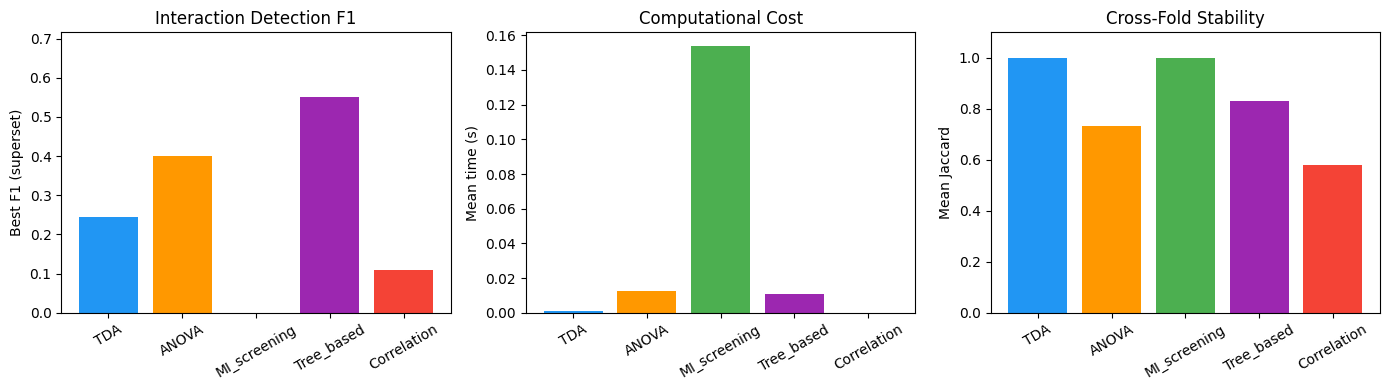


Figure saved to benchmark_results.png


In [14]:
# ── Compute summary metrics ──
best_thresholds: Dict[str, float] = {}
best_f1: Dict[str, float] = {}
mean_times: Dict[str, float] = {}
mean_jaccards: Dict[str, float] = {}

for method_name in METHOD_THRESHOLDS:
    thresh_f1: Dict[float, List[float]] = defaultdict(list)
    all_times: List[float] = []
    all_jac: List[float] = []

    for ds_name, results in all_results.items():
        for r in results:
            if r["method"] == method_name:
                all_times.append(r["wall_clock_seconds"])
                if "jaccard_stability" in r:
                    all_jac.append(r["jaccard_stability"])
                if "f1_superset" in r:
                    thresh_f1[r["threshold"]].append(r["f1_superset"])

    if thresh_f1:
        bt = max(thresh_f1, key=lambda t: np.mean(thresh_f1[t]))
        best_thresholds[method_name] = round(bt, 6)
        best_f1[method_name] = round(float(np.mean(thresh_f1[bt])), 6)
    else:
        best_thresholds[method_name] = 0.0
        best_f1[method_name] = 0.0

    mean_times[method_name] = round(float(np.mean(all_times)) if all_times else 0.0, 4)
    mean_jaccards[method_name] = round(float(np.mean(all_jac)) if all_jac else 0.0, 6)

# ── Print summary table ──
print("=" * 65)
print(f"{'Method':<15} {'Best F1':>8} {'Threshold':>10} {'Time(s)':>8} {'Jaccard':>8}")
print("-" * 65)
for m in METHOD_THRESHOLDS:
    print(f"{m:<15} {best_f1[m]:>8.4f} {best_thresholds[m]:>10.4f} {mean_times[m]:>8.4f} {mean_jaccards[m]:>8.4f}")
print("=" * 65)

# ── Bar chart: Best F1 per method ──
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

methods = list(METHOD_THRESHOLDS.keys())
colors = ['#2196F3', '#FF9800', '#4CAF50', '#9C27B0', '#F44336']

# F1 scores
ax = axes[0]
f1_vals = [best_f1[m] for m in methods]
ax.bar(methods, f1_vals, color=colors)
ax.set_ylabel('Best F1 (superset)')
ax.set_title('Interaction Detection F1')
ax.set_ylim(0, max(f1_vals) * 1.3 if max(f1_vals) > 0 else 1.0)
ax.tick_params(axis='x', rotation=30)

# Mean time
ax = axes[1]
time_vals = [mean_times[m] for m in methods]
ax.bar(methods, time_vals, color=colors)
ax.set_ylabel('Mean time (s)')
ax.set_title('Computational Cost')
ax.tick_params(axis='x', rotation=30)

# Jaccard stability
ax = axes[2]
jac_vals = [mean_jaccards[m] for m in methods]
ax.bar(methods, jac_vals, color=colors)
ax.set_ylabel('Mean Jaccard')
ax.set_title('Cross-Fold Stability')
ax.set_ylim(0, 1.1)
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('benchmark_results.png', dpi=100, bbox_inches='tight')
plt.show()
print("\nFigure saved to benchmark_results.png")